# World Cup Agent Arena | Exploratory Data Analysis on API Data

## Import and Setup

In [1]:
import json
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

In [ ]:
# Credentials
ARENA_KEY      = "your_arena_key_here"
GEMINI_API_KEY = "your_gemini_api_key_here"

In [3]:
# Endpoints
ARENA            = "https://staging.stair-ai.com"
SPORTMONKS_PROXY = f"{ARENA}/api/v1/data/proxy/sportmonks/v3/football"
POLYMARKET_GAMMA = f"{ARENA}/api/v1/data/proxy/polymarket-gamma"
POLYMARKET_CLOB  = f"{ARENA}/api/v1/data/proxy/polymarket-clob"
SUPABASE         = "https://ezvbmtvrvzageqixvdak.supabase.co"
SUPABASE_KEY     = "sb_publishable__m8bOkD05ToFwATpaWST5w_2-3fGS7V"

In [4]:
# Headers
H_ARENA  = {"x-api-key": ARENA_KEY}
H_PUBLIC = {"apikey": SUPABASE_KEY}
H_WCA    = {"apikey": SUPABASE_KEY, "Accept-Profile": "world_cup_arena"}

In [5]:
SEASON_ID = 26618   # WC 2026

## Section 1 · Identity Resolution

Before querying anything, we resolve the team identities across all three systems.

Step 1a — Fetch the WC2026 schedule and pick a fixture

Step 1b — Extract Sportmonks team identities

Step 1c — Resolve Polymarket identities via the Arena mapping

Step 1d — Resolve Supabase / StatsBomb identities via dim_match

In [6]:
r = requests.get(
    f"{SPORTMONKS_PROXY}/schedules/seasons/{SEASON_ID}",
    headers=H_ARENA, timeout=15,
)
r.raise_for_status()

schedule = r.json()["body"]["data"]

print(f"HTTP {r.status_code} OK")
print(f"Total schedule entries: {len(schedule)}")
print(f"\nKeys in a schedule entry:")
print(list(schedule[0].keys()))

HTTP 200 OK
Total schedule entries: 7

Keys in a schedule entry:
['id', 'sport_id', 'league_id', 'season_id', 'type_id', 'name', 'sort_order', 'finished', 'is_current', 'starting_at', 'ending_at', 'games_in_current_week', 'tie_breaker_rule_id', 'rounds', 'aggregates']


In [7]:
# Look at the structure of the first entry
entry = schedule[0]
print(f"Stage name: {entry['name']}")
print(f"Finished: {entry['finished']}")
print(f"Keys: {list(entry.keys())}")
print(f"\n'rounds' is a: {type(entry['rounds'])}")
print(f"Number of rounds: {len(entry['rounds'])}")
print(f"\nFirst round keys:")
print(list(entry['rounds'][0].keys()))

Stage name: Group Stage
Finished: False
Keys: ['id', 'sport_id', 'league_id', 'season_id', 'type_id', 'name', 'sort_order', 'finished', 'is_current', 'starting_at', 'ending_at', 'games_in_current_week', 'tie_breaker_rule_id', 'rounds', 'aggregates']

'rounds' is a: <class 'list'>
Number of rounds: 3

First round keys:
['id', 'sport_id', 'league_id', 'season_id', 'stage_id', 'name', 'finished', 'is_current', 'starting_at', 'ending_at', 'games_in_current_week', 'fixtures']


In [ ]:
# Flatten stages → rounds → fixtures
fixtures = []
for stage in schedule:
    for round_ in (stage.get("rounds") or []):
        for fixture in (round_.get("fixtures") or []):
            fixtures.append({
                "fixture_id":  fixture["id"],
                "name":        fixture["name"],
                "kickoff":     fixture.get("starting_at"),
                "stage":       stage["name"],
                "round":       round_["name"],
                "finished":    fixture.get("result_info") is not None,
            })

df_fixtures = pd.DataFrame(fixtures)
print(f"Total fixtures found: {len(df_fixtures)}")
print(f"\nStages:")
print(df_fixtures["stage"].value_counts())
display(df_fixtures.head(10))

Total fixtures found: 72

Stages:
stage
Group Stage    72
Name: count, dtype: int64


,fixture_id,name,kickoff,stage,round,finished
0,19609167,Ghana vs Panama,2026-06-17 23:00:00,Group Stage,1,False
1,19609163,Iraq vs Norway,2026-06-16 22:00:00,Group Stage,1,False
2,19609165,Uzbekistan vs Colombia,2026-06-18 02:00:00,Group Stage,1,False
3,19609154,Canada vs Bosnia and Herzegovina,2026-06-12 19:00:00,Group Stage,1,False
4,19609166,Portugal vs Congo DR,2026-06-17 17:00:00,Group Stage,1,False
5,19609153,Korea Republic vs Czech Republic,2026-06-12 02:00:00,Group Stage,1,False
6,19609130,Qatar vs Switzerland,2026-06-13 19:00:00,Group Stage,1,False
7,19609143,France vs Senegal,2026-06-16 19:00:00,Group Stage,1,False
8,19609131,Brazil vs Morocco,2026-06-13 22:00:00,Group Stage,1,False
9,19609157,Côte d'Ivoire vs Ecuador,2026-06-14 23:00:00,Group Stage,1,False


In [9]:
# Search for Mexico fixture
mex_fixtures = df_fixtures[
    df_fixtures["name"].str.contains("Mexico", case=False, na=False)
]
print(f"Fixtures involving Mexico:")
display(mex_fixtures)

Fixtures involving Mexico:


,fixture_id,name,kickoff,stage,round,finished
18,19609127,Mexico vs South Africa,2026-06-11 19:00:00,Group Stage,1,False
31,19609128,Mexico vs Korea Republic,2026-06-19 01:00:00,Group Stage,2,False
54,19609185,Czech Republic vs Mexico,2026-06-25 01:00:00,Group Stage,3,False


In [10]:
# Pick Mexico vs South Africa - first upcoming fixture
FIXTURE_ROW = mex_fixtures.iloc[0]
SPORTMONKS_FIXTURE_ID = FIXTURE_ROW["fixture_id"]

print(f"Selected fixture:")
print(f"  Name     : {FIXTURE_ROW['name']}")
print(f"  Kickoff  : {FIXTURE_ROW['kickoff']}")
print(f"  Stage    : {FIXTURE_ROW['stage']} — {FIXTURE_ROW['round']}")
print(f"  Fixture ID: {SPORTMONKS_FIXTURE_ID}")

Selected fixture:
  Name     : Mexico vs South Africa
  Kickoff  : 2026-06-11 19:00:00
  Stage    : Group Stage — 1
  Fixture ID: 19609127


### Step 1b · Sportmonks Team Identities

Fetch the fixture detail and extract team identities - team_id, country_id, short_code for both home and away.

In [11]:
r = requests.get(
    f"{SPORTMONKS_PROXY}/fixtures/{SPORTMONKS_FIXTURE_ID}",
    params={"include": "participants"},
    headers=H_ARENA, timeout=15,
)
r.raise_for_status()

fixture = r.json()["body"]["data"]
participants = fixture["participants"]

home = next(p for p in participants if p["meta"]["location"] == "home")
away = next(p for p in participants if p["meta"]["location"] == "away")

# Build Sportmonks identity for both teams
sm_identities = pd.DataFrame([
    {
        "role":        "home",
        "name":        home["name"],
        "short_code":  home["short_code"],
        "team_id":     home["id"],
        "country_id":  home["country_id"],
    },
    {
        "role":        "away",
        "name":        away["name"],
        "short_code":  away["short_code"],
        "team_id":     away["id"],
        "country_id":  away["country_id"],
    },
])

print("Sportmonks identities:")
display(sm_identities)

Sportmonks identities:


,role,name,short_code,team_id,country_id
0,home,Mexico,MEX,18576,458
1,away,South Africa,ZAF,18555,146


### Step 1c · Polymarket Identities

Resolve Polymarket identities via the Arena mapping endpoint.
This gives us the event slug, condition IDs and token IDs for each outcome.

In [12]:
r = requests.get(
    f"{ARENA}/api/v1/web/mapping",
    params={"fixture_id": SPORTMONKS_FIXTURE_ID},
    headers=H_ARENA, timeout=10,
)
r.raise_for_status()

mappings = r.json().get("mappings") or []

if not mappings:
    print("No Polymarket mapping found for this fixture.")
    pm_identity = None
else:
    m = mappings[0]
    pm_identity = {
        "event_slug":          m["polymarket_event_slug"],
        "home_condition_id":   m["polymarket_home_condition_id"],
        "home_token_yes":      m["polymarket_home_token_yes"],
        "draw_condition_id":   m["polymarket_draw_condition_id"],
        "draw_token_yes":      m["polymarket_draw_token_yes"],
        "away_condition_id":   m["polymarket_away_condition_id"],
        "away_token_yes":      m["polymarket_away_token_yes"],
        "match_confidence":    m["match_confidence"],
    }

    print("Polymarket identities:")
    for k, v in pm_identity.items():
        print(f"  {k:25s} → {str(v)[:60]}")

Polymarket identities:
  event_slug                → fifwc-mex-rsa-2026-06-11
  home_condition_id         → 0x4cd77d456c83e7d8c569a8fb8f6396c3f40154f657e6d970733e2b1b6a
  home_token_yes            → 207790639982684744906998847148083102896591704779591154897412
  draw_condition_id         → 0x0a4b9beb6128863db2b107f185521597a426356f1d9a23c7001401edfd
  draw_token_yes            → 116341446738033254666431888343373003418037370960670922398347
  away_condition_id         → 0x17dfc75726fa95d4054d91e80295c8b3e494569617e67a7e620e27562b
  away_token_yes            → 115307860962719805060784163204351769077176612029040401546976
  match_confidence          → high


### Step 1d · Supabase / StatsBomb Identities

Resolve team identities in the Supabase database via dim_match.
We search by team name — NOT by Sportmonks IDs.

In [14]:
r = requests.get(
    f"{SUPABASE}/rest/v1/dim_match",
    params={"select": "*"},
    headers=H_WCA, timeout=10,
)
r.raise_for_status()

df_dim_match = pd.DataFrame(r.json())

# Search by name
home_name = home["name"]   # "Mexico"
away_name = away["name"]   # "South Africa"

# Build lookup: team_name → country_id from dim_match
id_lookup = {}
for _, row in df_dim_match.iterrows():
    id_lookup[row["team_name_a"]] = row["country_id_a"]
    id_lookup[row["team_name_b"]] = row["country_id_b"]

home_sb_id = id_lookup.get(home_name)
away_sb_id = id_lookup.get(away_name)

print(f"Supabase country_id for {home_name}: {home_sb_id}")
print(f"Supabase country_id for {away_name}: {away_sb_id}")

if away_sb_id is None:
    print(f"\n{away_name} not found in dim_match — no Supabase data available.")
if home_sb_id is None:
    print(f"\n{home_name} not found in dim_match — no Supabase data available.")

Supabase country_id for Mexico: 458
Supabase country_id for South Africa: None

South Africa not found in dim_match — no Supabase data available.


In [15]:
# Master identity map — single source of truth for all downstream queries
identity_map = {
    "fixture_id":   SPORTMONKS_FIXTURE_ID,
    "fixture_name": fixture["name"],
    "kickoff":      fixture["starting_at"],
    "home": {
        "name":           home["name"],
        "short_code":     home["short_code"],
        "sm_team_id":     home["id"],
        "sm_country_id":  home["country_id"],
        "sb_country_id":  home_sb_id,        # 458
        "pm_condition_id": pm_identity["home_condition_id"],
        "pm_token_yes":    pm_identity["home_token_yes"],
        "has_supabase":   home_sb_id is not None,
    },
    "away": {
        "name":           away["name"],
        "short_code":     away["short_code"],
        "sm_team_id":     away["id"],
        "sm_country_id":  away["country_id"],
        "sb_country_id":  away_sb_id,        # None
        "pm_condition_id": pm_identity["away_condition_id"],
        "pm_token_yes":    pm_identity["away_token_yes"],
        "has_supabase":   away_sb_id is not None,
    },
    "draw": {
        "pm_condition_id": pm_identity["draw_condition_id"],
        "pm_token_yes":    pm_identity["draw_token_yes"],
    },
    "pm_event_slug": pm_identity["event_slug"],
}

print(f"Identity map built for: {identity_map['fixture_name']}\n")
print(f"HOME — {identity_map['home']['name']}")
print(f"  Sportmonks team_id  : {identity_map['home']['sm_team_id']}")
print(f"  Sportmonks country_id: {identity_map['home']['sm_country_id']}")
print(f"  Supabase country_id : {identity_map['home']['sb_country_id']}")
print(f"  Has Supabase data   : {identity_map['home']['has_supabase']}")
print(f"\nAWAY — {identity_map['away']['name']}")
print(f"  Sportmonks team_id  : {identity_map['away']['sm_team_id']}")
print(f"  Sportmonks country_id: {identity_map['away']['sm_country_id']}")
print(f"  Supabase country_id : {identity_map['away']['sb_country_id']}")
print(f"  Has Supabase data   : {identity_map['away']['has_supabase']}")
print(f"\nPolymarket slug: {identity_map['pm_event_slug']}")

Identity map built for: Mexico vs South Africa

HOME — Mexico
  Sportmonks team_id  : 18576
  Sportmonks country_id: 458
  Supabase country_id : 458
  Has Supabase data   : True

AWAY — South Africa
  Sportmonks team_id  : 18555
  Sportmonks country_id: 146
  Supabase country_id : None
  Has Supabase data   : False

Polymarket slug: fifwc-mex-rsa-2026-06-11


## Section 2 · Sportmonks - Data Exploration

Using the identity map, we fetch the full fixture detail
and explore each data type: participants, ML predictions,
bookmaker odds, and expected goals.

In [16]:
r = requests.get(
    f"{SPORTMONKS_PROXY}/fixtures/{SPORTMONKS_FIXTURE_ID}",
    params={"include": "participants;predictions;odds;xgfixture"},
    headers=H_ARENA, timeout=15,
)
r.raise_for_status()

fixture_full = r.json()["body"]["data"]

print(f"HTTP {r.status_code} OK")
print(f"Fixture : {fixture_full['name']}")
print(f"Kickoff : {fixture_full['starting_at']}\n")
print("Data available:")
print(f"  participants : {len(fixture_full.get('participants') or [])} rows")
print(f"  predictions  : {len(fixture_full.get('predictions') or [])} rows")
print(f"  odds         : {len(fixture_full.get('odds') or [])} rows")
print(f"  xgfixture    : {len(fixture_full.get('xgfixture') or [])} rows")

HTTP 200 OK
Fixture : Mexico vs South Africa
Kickoff : 2026-06-11 19:00:00

Data available:
  participants : 2 rows
  predictions  : 28 rows
  odds         : 2340 rows
  xgfixture    : 0 rows


### Section 2a · Predictions — ML Models

In [17]:
predictions = fixture_full["predictions"]

# Separate by shape
one_x_two  = [p for p in predictions if "home" in (p.get("predictions") or {})]
yes_no     = [p for p in predictions if list((p.get("predictions") or {}).keys()) == ["yes", "no"]]
yes_no_eq  = [p for p in predictions if "equal" in (p.get("predictions") or {})]
other      = [p for p in predictions if p not in one_x_two + yes_no + yes_no_eq]

print(f"Total prediction rows : {len(predictions)}")
print(f"  1X2 (home/draw/away): {len(one_x_two)}")
print(f"  yes/no              : {len(yes_no)}")
print(f"  yes/no/equal        : {len(yes_no_eq)}")
print(f"  other               : {len(other)}")

# Build 1X2 dataframe
df_1x2 = pd.DataFrame([
    {
        "type_id":    p["type_id"],
        "home (MEX)": float(p["predictions"]["home"]),
        "draw":       float(p["predictions"]["draw"]),
        "away (ZAF)": float(p["predictions"]["away"]),
        "sum":        round(float(p["predictions"]["home"]) +
                            float(p["predictions"]["draw"]) +
                            float(p["predictions"]["away"]), 1),
    }
    for p in one_x_two
])

print("\n── 1X2 Models ──")
display(df_1x2)

Total prediction rows : 28
  1X2 (home/draw/away): 3
  yes/no              : 13
  yes/no/equal        : 9
  other               : 3

── 1X2 Models ──


,type_id,home (MEX),draw,away (ZAF),sum
0,233,28.40,46.08,25.52,100.0
1,237,40.84,27.78,31.38,100.0
2,238,50.35,9.54,40.11,100.0


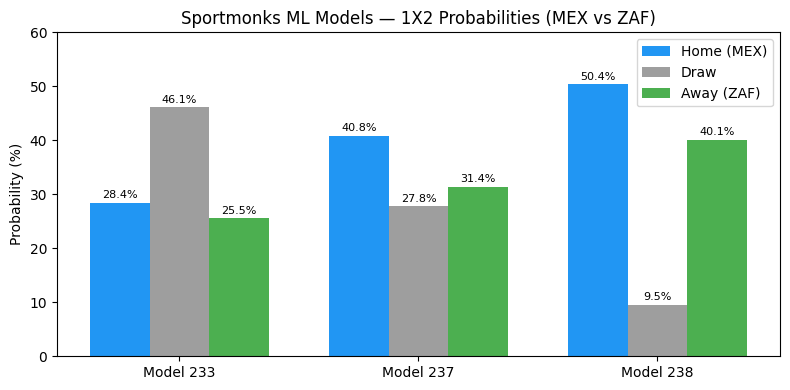


ML model consensus (simple average across 3 models):
  Home (MEX) : 39.9%
  Draw       : 27.8%
  Away (ZAF) : 32.3%


In [18]:
fig, ax = plt.subplots(figsize=(8, 4))

x     = range(len(df_1x2))
width = 0.25

ax.bar([i - width for i in x], df_1x2["home (MEX)"], width=width, label="Home (MEX)", color="#2196F3")
ax.bar([i          for i in x], df_1x2["draw"],       width=width, label="Draw",       color="#9E9E9E")
ax.bar([i + width for i in x], df_1x2["away (ZAF)"], width=width, label="Away (ZAF)", color="#4CAF50")

ax.set_xticks(list(x))
ax.set_xticklabels([f"Model {t}" for t in df_1x2["type_id"]])
ax.set_ylabel("Probability (%)")
ax.set_title("Sportmonks ML Models — 1X2 Probabilities (MEX vs ZAF)")
ax.legend()
ax.set_ylim(0, 60)

for bar in ax.patches:
    ax.annotate(f"{bar.get_height():.1f}%",
                (bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5),
                ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

# Compute the average across 3 models as consensus
consensus = {
    "home (MEX)": round(df_1x2["home (MEX)"].mean(), 1),
    "draw":       round(df_1x2["draw"].mean(), 1),
    "away (ZAF)": round(df_1x2["away (ZAF)"].mean(), 1),
}
print(f"\nML model consensus (simple average across 3 models):")
print(f"  Home (MEX) : {consensus['home (MEX)']}%")
print(f"  Draw       : {consensus['draw']}%")
print(f"  Away (ZAF) : {consensus['away (ZAF)']}%")

### Section 2b · Bookmaker Odds

In [19]:
odds = fixture_full["odds"]
odds_1x2 = [o for o in odds if o.get("market_id") == 1]

print(f"Total odds rows  : {len(odds)}")
print(f"1X2 market rows  : {len(odds_1x2)}")
print(f"Unique bookmakers: {len(set(o['bookmaker_id'] for o in odds_1x2))}\n")

# Build clean dataframe
odds_rows = []
for o in odds_1x2:
    prob_raw = (o.get("probability") or "0").replace("%", "").strip()
    odds_rows.append({
        "bookmaker_id": o["bookmaker_id"],
        "outcome":      o["label"],
        "decimal_odds": float(o.get("value") or 0),
        "implied_prob": round(float(prob_raw), 1),
        "updated":      (o.get("latest_bookmaker_update") or "")[:16],
    })

df_odds = pd.DataFrame(odds_rows).sort_values(["bookmaker_id", "outcome"])

# Consensus per outcome
consensus_odds = df_odds.groupby("outcome")["implied_prob"].agg(
    mean="mean", min="min", max="max", std="std"
).round(2).reset_index()

print("── Bookmaker consensus ──")
display(consensus_odds)

Total odds rows  : 2340
1X2 market rows  : 48
Unique bookmakers: 16

── Bookmaker consensus ──


,outcome,mean,min,max,std
0,Away,12.72,11.5,14.8,0.99
1,Draw,23.04,22.0,25.0,0.85
2,Home,70.08,66.7,73.5,1.64


### Section 2c · ML Models vs Bookmaker Consensus — Comparison

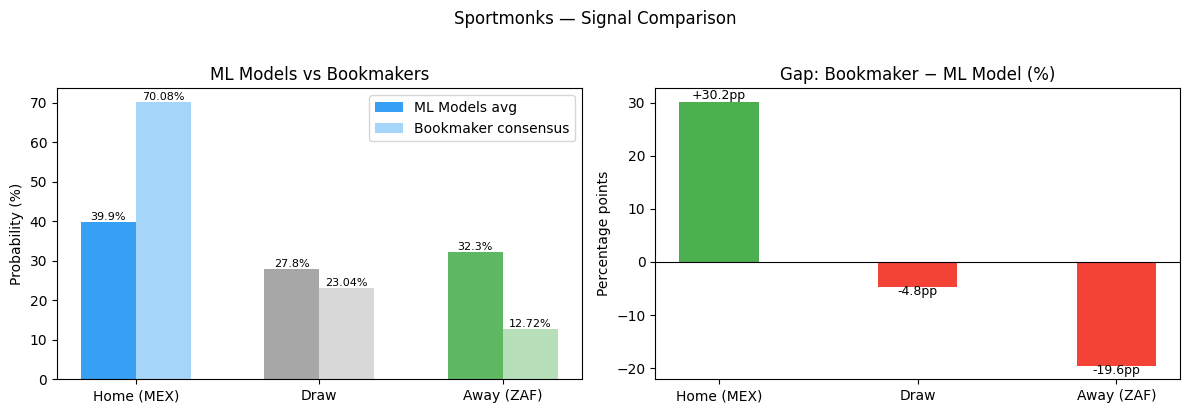

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

outcomes = ["Home (MEX)", "Draw", "Away (ZAF)"]
ml_vals  = [consensus["home (MEX)"], consensus["draw"], consensus["away (ZAF)"]]
bk_vals  = [70.08, 23.04, 12.72]
colors   = ["#2196F3", "#9E9E9E", "#4CAF50"]

# ── Left: side by side bar ────────────────────────────────────
x     = range(len(outcomes))
width = 0.3

axes[0].bar([i - width/2 for i in x], ml_vals, width=width,
            color=colors, label="ML Models avg", alpha=0.9)
axes[0].bar([i + width/2 for i in x], bk_vals, width=width,
            color=colors, label="Bookmaker consensus", alpha=0.4)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(outcomes)
axes[0].set_ylabel("Probability (%)")
axes[0].set_title("ML Models vs Bookmakers")
axes[0].legend()
for i, (ml, bk) in enumerate(zip(ml_vals, bk_vals)):
    axes[0].annotate(f"{ml}%", (i - width/2, ml + 0.5), ha="center", fontsize=8)
    axes[0].annotate(f"{bk}%", (i + width/2, bk + 0.5), ha="center", fontsize=8)

# ── Right: gap (bookmaker - ML) ───────────────────────────────
gaps = [bk - ml for bk, ml in zip(bk_vals, ml_vals)]
bar_colors = ["#4CAF50" if g > 0 else "#F44336" for g in gaps]
axes[1].bar(outcomes, gaps, color=bar_colors, width=0.4)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Gap: Bookmaker − ML Model (%)")
axes[1].set_ylabel("Percentage points")
for i, g in enumerate(gaps):
    axes[1].annotate(f"{g:+.1f}pp",
                     (i, g + (0.5 if g >= 0 else -1.5)),
                     ha="center", fontsize=9)

plt.suptitle("Sportmonks — Signal Comparison", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Section 3 · Polymarket — Market Exploration

Using the identity map's event slug and token IDs,
we fetch the Gamma event structure and live CLOB prices.

In [21]:
r = requests.get(
    f"{POLYMARKET_GAMMA}/events",
    params={"slug": identity_map["pm_event_slug"]},
    headers=H_ARENA, timeout=15,
)
r.raise_for_status()

events = r.json().get("body") or []
event  = events[0] if events else None

print(f"HTTP {r.status_code} OK")
print(f"Event  : {event['title']}")
print(f"Active : {event['active']}")
print(f"Closed : {event['closed']}")
print(f"\nMarket summary:")
print(f"  Liquidity   : ${float(event['liquidity']):,.0f}")
print(f"  Volume total: ${float(event['volume']):,.0f}")
print(f"  Volume 24hr : ${float(event['volume24hr']):,.0f}")
print(f"  Competitive : {event['competitive']}")
print(f"  negRisk     : {event['negRisk']}")
print(f"\nChild markets: {len(event['markets'])}")

HTTP 200 OK
Event  : Mexico vs. South Africa
Active : True
Closed : False

Market summary:
  Liquidity   : $654,627
  Volume total: $320,255
  Volume 24hr : $89,257
  Competitive : 0.9669075878072954
  negRisk     : True

Child markets: 3


In [22]:
def get_clob_mid(token_yes):
    try:
        r = requests.get(
            f"{POLYMARKET_CLOB}/midpoint",
            params={"token_id": token_yes},
            headers=H_ARENA, timeout=10,
        )
        if r.ok:
            body = r.json().get("body")
            if isinstance(body, dict) and "mid" in body:
                return float(body["mid"])
    except Exception:
        pass
    return None

# Fetch live mids using token IDs from identity map
home_mid = get_clob_mid(identity_map["home"]["pm_token_yes"])
draw_mid = get_clob_mid(identity_map["draw"]["pm_token_yes"])
away_mid = get_clob_mid(identity_map["away"]["pm_token_yes"])

df_pm = pd.DataFrame([
    {"outcome": "Home (MEX)", "mid_price": home_mid, "implied_prob": f"{home_mid*100:.1f}%"},
    {"outcome": "Draw",       "mid_price": draw_mid, "implied_prob": f"{draw_mid*100:.1f}%"},
    {"outcome": "Away (ZAF)", "mid_price": away_mid, "implied_prob": f"{away_mid*100:.1f}%"},
])

print("── Live CLOB mid prices ──")
display(df_pm)
print(f"\nSum of mids: {round(home_mid + draw_mid + away_mid, 4)}")

── Live CLOB mid prices ──


,outcome,mid_price,implied_prob
0,Home (MEX),0.685,68.5%
1,Draw,0.205,20.5%
2,Away (ZAF),0.105,10.5%



Sum of mids: 0.995


### Section 3a · All Three Sources — Final Comparison

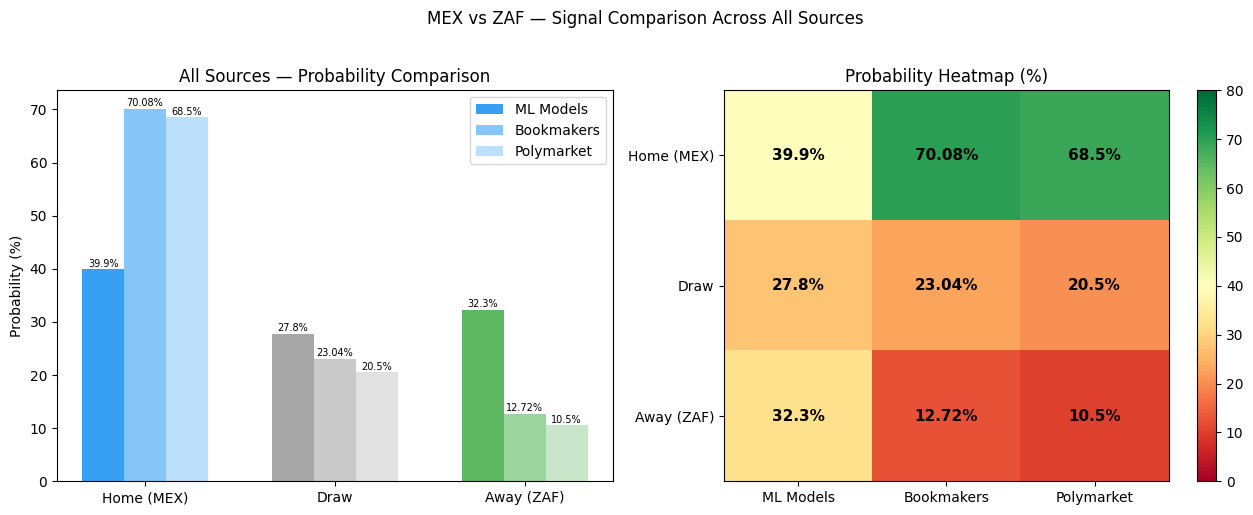

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

outcomes = ["Home (MEX)", "Draw", "Away (ZAF)"]
ml_vals  = [39.9, 27.8, 32.3]
bk_vals  = [70.08, 23.04, 12.72]
pm_vals  = [68.5, 20.5, 10.5]
colors   = ["#2196F3", "#9E9E9E", "#4CAF50"]

# ── Left: all three sources side by side ──────────────────────
x     = range(len(outcomes))
width = 0.22

axes[0].bar([i - width for i in x],   ml_vals, width=width, color=colors, alpha=0.9,  label="ML Models")
axes[0].bar([i          for i in x],   bk_vals, width=width, color=colors, alpha=0.55, label="Bookmakers")
axes[0].bar([i + width for i in x],   pm_vals, width=width, color=colors, alpha=0.3,  label="Polymarket")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(outcomes)
axes[0].set_ylabel("Probability (%)")
axes[0].set_title("All Sources — Probability Comparison")
axes[0].legend()

for i, (ml, bk, pm) in enumerate(zip(ml_vals, bk_vals, pm_vals)):
    axes[0].annotate(f"{ml}%",  (i - width, ml + 0.5), ha="center", fontsize=7)
    axes[0].annotate(f"{bk}%",  (i,          bk + 0.5), ha="center", fontsize=7)
    axes[0].annotate(f"{pm}%",  (i + width,  pm + 0.5), ha="center", fontsize=7)

# ── Right: summary table as heatmap-style ─────────────────────
df_compare = pd.DataFrame({
    "ML Models":   ml_vals,
    "Bookmakers":  bk_vals,
    "Polymarket":  pm_vals,
}, index=outcomes)

im = axes[1].imshow(df_compare.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=80)
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(df_compare.columns)
axes[1].set_yticks(range(3))
axes[1].set_yticklabels(df_compare.index)
axes[1].set_title("Probability Heatmap (%)")

for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f"{df_compare.values[i,j]}%",
                     ha="center", va="center", fontsize=11, fontweight="bold")

plt.colorbar(im, ax=axes[1])
plt.suptitle("MEX vs ZAF — Signal Comparison Across All Sources", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Section 4 · Supabase — Historical Stats

Using the identity map, we query Supabase with the correct IDs.
Mexico → sb_country_id 458
South Africa → no data (not in database)

We explore all three categories: priors, checkpoint, dimension.

In [24]:
home_sb_id = identity_map["home"]["sb_country_id"]   # 458
away_sb_id = identity_map["away"]["sb_country_id"]   # None

print(f"Home ({identity_map['home']['name']}) Supabase ID : {home_sb_id}")
print(f"Away ({identity_map['away']['name']}) Supabase ID : {away_sb_id}")
print(f"\nHome has Supabase data : {identity_map['home']['has_supabase']}")
print(f"Away has Supabase data : {identity_map['away']['has_supabase']}")
print(f"\nNote: all Supabase queries will be Mexico-only.")
print(f"South Africa has no data in this database (did not qualify for 2022 WC).")

Home (Mexico) Supabase ID : 458
Away (South Africa) Supabase ID : None

Home has Supabase data : True
Away has Supabase data : False

Note: all Supabase queries will be Mexico-only.
South Africa has no data in this database (did not qualify for 2022 WC).


### Section 4a · Dimension Tables

In [25]:
# Fetch dim_match
r = requests.get(
    f"{SUPABASE}/rest/v1/dim_match",
    params={"select": "*"},
    headers=H_WCA, timeout=10,
)
r.raise_for_status()
df_dim_match = pd.DataFrame(r.json())

# Filter to Mexico only
mex_matches = df_dim_match[
    (df_dim_match["team_name_a"] == identity_map["home"]["name"]) |
    (df_dim_match["team_name_b"] == identity_map["home"]["name"])
].copy()

# Add result column for context
mex_matches["mex_side"] = mex_matches.apply(
    lambda r: "home" if r["team_name_a"] == "Mexico" else "away", axis=1
)

print(f"Total matches in database : {len(df_dim_match)}")
print(f"Mexico matches            : {len(mex_matches)}\n")
print("Mexico's matches:")
display(mex_matches[["match_id", "kickoff_at", "team_name_a", "team_name_b",
                      "stage_canonical", "is_knockout", "mex_side"]].reset_index(drop=True))

Total matches in database : 65
Mexico matches            : 3

Mexico's matches:


,match_id,kickoff_at,team_name_a,team_name_b,stage_canonical,is_knockout,mex_side
0,18494068,2022-11-30T19:00:00+00:00,Saudi Arabia,Mexico,group,False,away
1,18493997,2022-11-22T16:00:00+00:00,Mexico,Poland,group,False,home
2,18494065,2022-11-26T19:00:00+00:00,Argentina,Mexico,group,False,away


In [26]:
# Store Mexico's match IDs and opponent lookup
mex_match_ids = mex_matches["match_id"].tolist()
mex_team_id   = identity_map["home"]["sm_team_id"]   # 18576

opponent_lookup = {}
for _, row in mex_matches.iterrows():
    if row["team_name_a"] == "Mexico":
        opponent_lookup[row["match_id"]] = f"vs {row['team_name_b']}"
    else:
        opponent_lookup[row["match_id"]] = f"vs {row['team_name_a']}"

print(f"Mexico team_id : {mex_team_id}")
print(f"Match IDs      : {mex_match_ids}")
print(f"Opponents      : {opponent_lookup}")

Mexico team_id : 18576
Match IDs      : [18494068, 18493997, 18494065]
Opponents      : {18494068: 'vs Saudi Arabia', 18493997: 'vs Poland', 18494065: 'vs Argentina'}


### Section 4b · Checkpoint Snapshot — Mexico 2022 WC

In [27]:
r = requests.get(
    f"{SUPABASE}/rest/v1/d_checkpoint_snapshot",
    params={"select": "*"},
    headers=H_WCA, timeout=10,
)
r.raise_for_status()

df_snap = pd.DataFrame(r.json())

# Filter to Mexico's matches and Mexico's team_id
mex_snap = df_snap[
    (df_snap["match_id"].isin(mex_match_ids)) &
    (df_snap["team_id"] == mex_team_id)
].copy()

# Add opponent and checkpoint labels
mex_snap["opponent"] = mex_snap["match_id"].map(opponent_lookup)

print(f"Total snapshot rows      : {len(df_snap)}")
print(f"Mexico rows              : {len(mex_snap)}")
print(f"Checkpoints available    : {mex_snap['checkpoint_code'].unique()}\n")

display(mex_snap[["opponent", "checkpoint_code", "is_home",
                   "cum_goals", "cum_shots_total", "cum_shots_on_target",
                   "cum_possession_pct", "cum_pass_accuracy_pct",
                   "cum_yellow_cards", "cum_red_cards"]].reset_index(drop=True))

Total snapshot rows      : 260
Mexico rows              : 6
Checkpoints available    : <StringArray>
['HT', 'FT']
Length: 2, dtype: str



,opponent,checkpoint_code,is_home,cum_goals,cum_shots_total,cum_shots_on_target,cum_possession_pct,cum_pass_accuracy_pct,cum_yellow_cards,cum_red_cards
0,vs Poland,HT,True,0,0,0,NaN,NaN,1,0
1,vs Poland,FT,True,0,11,4,61.0,0.835729,2,0
2,vs Argentina,HT,False,0,0,0,NaN,NaN,1,0
3,vs Argentina,FT,False,0,4,1,41.0,0.767568,4,0
4,vs Saudi Arabia,HT,False,0,0,0,NaN,NaN,1,0
5,vs Saudi Arabia,FT,False,2,26,11,61.0,0.751174,1,0


In [28]:
mex_ft = mex_snap[mex_snap["checkpoint_code"] == "FT"].copy()
mex_ft = mex_ft.sort_values("opponent").reset_index(drop=True)

# Add result column manually — we know these from 2022
results = {
    "vs Poland":       "0-0 (D)",
    "vs Argentina":    "0-2 (L)",
    "vs Saudi Arabia": "2-1 (W)",
}
mex_ft["result"] = mex_ft["opponent"].map(results)
mex_ft["label"]  = mex_ft["opponent"] + "\n" + mex_ft["result"]

print("Mexico FT stats — 2022 WC Group Stage:")
display(mex_ft[["label", "is_home", "cum_goals", "cum_shots_total",
                 "cum_shots_on_target", "cum_possession_pct",
                 "cum_pass_accuracy_pct", "cum_yellow_cards"]].reset_index(drop=True))

Mexico FT stats — 2022 WC Group Stage:


,label,is_home,cum_goals,cum_shots_total,cum_shots_on_target,cum_possession_pct,cum_pass_accuracy_pct,cum_yellow_cards
0,vs Argentina\n0-2 (L),False,0,4,1,41.0,0.767568,4
1,vs Poland\n0-0 (D),True,0,11,4,61.0,0.835729,2
2,vs Saudi Arabia\n2-1 (W),False,2,26,11,61.0,0.751174,1


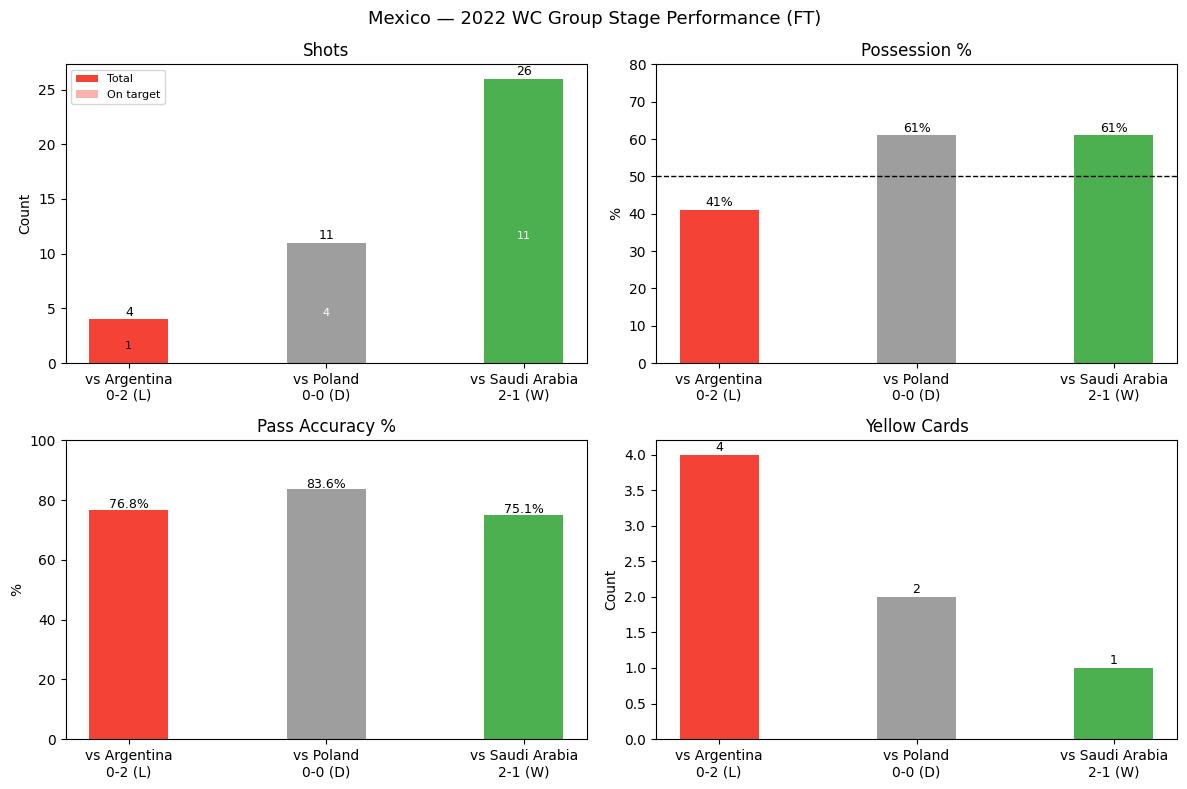

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

labels  = mex_ft["label"].tolist()
colors  = ["#F44336", "#9E9E9E", "#4CAF50"]   # red=loss, grey=draw, green=win

# ── Top left: shots ───────────────────────────────────────────
axes[0,0].bar(labels, mex_ft["cum_shots_total"],     color=colors, width=0.4, label="Total")
axes[0,0].bar(labels, mex_ft["cum_shots_on_target"], color=colors, width=0.4, alpha=0.4, label="On target")
axes[0,0].set_title("Shots")
axes[0,0].set_ylabel("Count")
axes[0,0].legend(fontsize=8)
for i, (tot, ont) in enumerate(zip(mex_ft["cum_shots_total"], mex_ft["cum_shots_on_target"])):
    axes[0,0].annotate(f"{tot}", (i, tot + 0.3), ha="center", fontsize=9)
    axes[0,0].annotate(f"{ont}", (i, ont + 0.3), ha="center", fontsize=8, color="white" if ont > 3 else "black")

# ── Top right: possession ─────────────────────────────────────
axes[0,1].bar(labels, mex_ft["cum_possession_pct"], color=colors, width=0.4)
axes[0,1].axhline(50, color="black", linestyle="--", linewidth=1)
axes[0,1].set_title("Possession %")
axes[0,1].set_ylabel("%")
axes[0,1].set_ylim(0, 80)
for i, val in enumerate(mex_ft["cum_possession_pct"]):
    axes[0,1].annotate(f"{val:.0f}%", (i, val + 1), ha="center", fontsize=9)

# ── Bottom left: pass accuracy ────────────────────────────────
axes[1,0].bar(labels, mex_ft["cum_pass_accuracy_pct"] * 100, color=colors, width=0.4)
axes[1,0].set_title("Pass Accuracy %")
axes[1,0].set_ylabel("%")
axes[1,0].set_ylim(0, 100)
for i, val in enumerate(mex_ft["cum_pass_accuracy_pct"] * 100):
    axes[1,0].annotate(f"{val:.1f}%", (i, val + 0.5), ha="center", fontsize=9)

# ── Bottom right: yellow cards ────────────────────────────────
axes[1,1].bar(labels, mex_ft["cum_yellow_cards"], color=colors, width=0.4)
axes[1,1].set_title("Yellow Cards")
axes[1,1].set_ylabel("Count")
for i, val in enumerate(mex_ft["cum_yellow_cards"]):
    axes[1,1].annotate(f"{val}", (i, val + 0.05), ha="center", fontsize=9)

plt.suptitle("Mexico — 2022 WC Group Stage Performance (FT)", fontsize=13)
plt.tight_layout()
plt.show()

### Section 4c · Priors Tables — Mexico only

We query all 8 priors tables using the correct Supabase ID (458).
South Africa is skipped — no data available.

In [30]:
priors_tables = [
    "ads_a_country_style",
    "ads_a_country_struct",
    "ads_a_h2h_country",
    "ads_a_ko_pattern",
    "ads_a_manager",
    "ads_a_special_match",
    "ads_a_stage_record",
    "ads_a_h2h_continent",
]

priors_data = {}

for table in priors_tables:
    r = requests.get(
        f"{SUPABASE}/rest/v1/{table}",
        params={"select": "*"},
        headers=H_WCA, timeout=10,
    )
    r.raise_for_status()
    df = pd.DataFrame(r.json())
    
    # Filter to Mexico where possible
    if "country_id" in df.columns:
        mex_df = df[df["country_id"] == home_sb_id]
    elif "country_id_a" in df.columns:
        mex_df = df[df["country_id_a"] == home_sb_id]
    else:
        mex_df = df
    
    priors_data[table] = mex_df
    print(f"  {table:30s} → total={len(df):4d} rows  mexico={len(mex_df)} rows")

  ads_a_country_style            → total=  71 rows  mexico=0 rows
  ads_a_country_struct           → total=  66 rows  mexico=0 rows
  ads_a_h2h_country              → total=1000 rows  mexico=0 rows
  ads_a_ko_pattern               → total=  71 rows  mexico=0 rows
  ads_a_manager                  → total= 206 rows  mexico=206 rows
  ads_a_special_match            → total=  36 rows  mexico=0 rows
  ads_a_stage_record             → total= 180 rows  mexico=0 rows
  ads_a_h2h_continent            → total=  28 rows  mexico=28 rows


In [31]:
# Check what country_ids exist in ads_a_country_style
df_style = pd.DataFrame(requests.get(
    f"{SUPABASE}/rest/v1/ads_a_country_style",
    params={"select": "*"},
    headers=H_WCA, timeout=10,
).json())

print("Sample country_ids in ads_a_country_style:")
print(sorted(df_style["country_id"].tolist()))

Sample country_ids in ads_a_country_style:
[3, 11, 14, 15, 22, 27, 31, 39, 40, 45, 46, 49, 54, 56, 60, 61, 65, 66, 68, 77, 78, 84, 85, 86, 98, 103, 104, 107, 109, 112, 113, 114, 121, 135, 147, 154, 160, 163, 166, 169, 171, 176, 178, 179, 180, 182, 183, 185, 187, 188, 200, 201, 202, 203, 207, 208, 211, 214, 220, 221, 226, 232, 233, 238, 241, 242, 246, 247, 249, 253, 255]


In [32]:
df_manager = pd.DataFrame(requests.get(
    f"{SUPABASE}/rest/v1/ads_a_manager",
    params={"select": "*"},
    headers=H_WCA, timeout=10,
).json())

print(f"Columns: {list(df_manager.columns)}\n")
display(df_manager.head(5))

Columns: ['manager_id', 'manager_name', 'tenure_years', 'tournaments_coached_count', 'worldcups_coached_count', 'ko_matches', 'ko_wins', 'ko_draws', 'ko_losses', 'ko_win_rate']



,manager_id,manager_name,tenure_years,tournaments_coached_count,worldcups_coached_count,ko_matches,ko_wins,ko_draws,ko_losses,ko_win_rate
0,45,Sarina Glotzbach-Wiegman,6.13,4,0,13.0,8.0,3.0,2.0,0.615385
1,46,Andries Jonker,1.97,2,0,2.0,1.0,0.0,1.0,0.500000
2,48,Domenico Tedesco,0.04,1,0,1.0,0.0,0.0,1.0,0.000000
3,53,Martina Voss-Tecklenburg,4.15,3,0,4.0,3.0,0.0,1.0,0.750000
4,93,Gregg Berhalter,1.61,2,1,1.0,0.0,0.0,1.0,0.000000


In [33]:
df_stage = pd.DataFrame(requests.get(
    f"{SUPABASE}/rest/v1/ads_a_stage_record",
    params={"select": "*"},
    headers=H_WCA, timeout=10,
).json())

print(f"Columns: {list(df_stage.columns)}\n")
display(df_stage.head(5))

Columns: ['country_id', 'stage_canonical', 'matches', 'wins', 'draws', 'losses', 'win_rate']



,country_id,stage_canonical,matches,wins,draws,losses,win_rate
0,31,final,2,2,0,0,1.0
1,31,sf,2,2,0,0,1.0
2,179,qf,1,0,0,1,0.0
3,220,final,1,0,0,1,0.0
4,255,group,2,1,0,1,0.5


In [34]:
df_h2h = pd.DataFrame(requests.get(
    f"{SUPABASE}/rest/v1/ads_a_h2h_country",
    params={"select": "*"},
    headers=H_WCA, timeout=10,
).json())

# Build country_name → country_id lookup
name_to_id = {}
for _, row in df_h2h.iterrows():
    name_to_id[row["country_name_a"]] = row["country_id_a"]
    name_to_id[row["country_name_b"]] = row["country_id_b"]

print("Looking up Mexico and South Africa:")
print(f"  Mexico       → {name_to_id.get('Mexico', 'NOT FOUND')}")
print(f"  South Africa → {name_to_id.get('South Africa', 'NOT FOUND')}")

print("\nAll country names in this lookup:")
print(sorted(name_to_id.keys()))

Looking up Mexico and South Africa:
  Mexico       → 147
  South Africa → 211

All country names in this lookup:
['Albania', 'Argentina', 'Australia', 'Austria', 'Belgium', 'Bolivia', 'Brazil', 'Cameroon', 'Canada', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Czech Republic', 'Denmark', 'Ecuador', 'Egypt', 'England', 'Finland', 'France', 'Georgia', 'Germany', 'Ghana', 'Haiti', 'Hungary', 'Iceland', 'International', 'Iran', 'Ireland', 'Italy', 'Jamaica', 'Japan', 'Korea\xa0(South)', 'Macedonia, Republic of', 'Mexico', 'Morocco', 'Netherlands', 'New Zealand', 'Nigeria', 'Northern Ireland', 'Norway', 'Panama', 'Paraguay', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Qatar', 'Romania', 'Russia', 'Saudi Arabia', 'Scotland', 'Senegal', 'Serbia', 'Slovakia', 'Slovenia', 'South Africa', 'Spain', 'Sweden', 'Switzerland', 'Thailand', 'Tunisia', 'Turkey', 'USA', 'Ukraine', 'Uruguay', 'Venezuela\xa0(Bolivarian Republic)', 'Vietnam', 'Wales', 'Zambia']


In [35]:
# Update identity map with correct StatsBomb priors IDs
identity_map["home"]["sb_priors_id"] = name_to_id.get("Mexico")
identity_map["away"]["sb_priors_id"] = name_to_id.get("South Africa")

print(f"Mexico       StatsBomb priors ID : {identity_map['home']['sb_priors_id']}")
print(f"South Africa StatsBomb priors ID : {identity_map['away']['sb_priors_id']}")

# Now re-query all priors tables with correct IDs
home_priors_id = identity_map["home"]["sb_priors_id"]   # 147
away_priors_id = identity_map["away"]["sb_priors_id"]   # 211

print(f"\nRe-querying all priors tables with IDs {home_priors_id} and {away_priors_id}...\n")

priors_data = {}
for table in priors_tables:
    r = requests.get(
        f"{SUPABASE}/rest/v1/{table}",
        params={"select": "*"},
        headers=H_WCA, timeout=10,
    )
    r.raise_for_status()
    df = pd.DataFrame(r.json())

    if "country_id" in df.columns:
        mex_df = df[df["country_id"].isin([home_priors_id, away_priors_id])]
    elif "country_id_a" in df.columns:
        mex_df = df[
            (df["country_id_a"].isin([home_priors_id, away_priors_id])) |
            (df["country_id_b"].isin([home_priors_id, away_priors_id]))
        ]
    else:
        mex_df = pd.DataFrame()

    priors_data[table] = mex_df
    print(f"  {table:30s} → total={len(df):4d}  mex/zaf={len(mex_df)} rows")

Mexico       StatsBomb priors ID : 147
South Africa StatsBomb priors ID : 211

Re-querying all priors tables with IDs 147 and 211...

  ads_a_country_style            → total=  71  mex/zaf=2 rows
  ads_a_country_struct           → total=  66  mex/zaf=2 rows
  ads_a_h2h_country              → total=1000  mex/zaf=39 rows
  ads_a_ko_pattern               → total=  71  mex/zaf=2 rows
  ads_a_manager                  → total= 206  mex/zaf=0 rows
  ads_a_special_match            → total=  36  mex/zaf=1 rows
  ads_a_stage_record             → total= 180  mex/zaf=4 rows
  ads_a_h2h_continent            → total=  28  mex/zaf=0 rows


In [36]:
# Final complete identity map — all three systems
print("=" * 55)
print("FINAL IDENTITY MAP")
print("=" * 55)
print(f"\nFixture  : {identity_map['fixture_name']}")
print(f"Kickoff  : {identity_map['kickoff']}")
print(f"\n{'System':<25} {'Mexico':>10} {'South Africa':>15}")
print("-" * 55)
print(f"{'Sportmonks team_id':<25} {identity_map['home']['sm_team_id']:>10} {identity_map['away']['sm_team_id']:>15}")
print(f"{'Sportmonks country_id':<25} {identity_map['home']['sm_country_id']:>10} {identity_map['away']['sm_country_id']:>15}")
print(f"{'Supabase dim_match id':<25} {identity_map['home']['sb_country_id']:>10} {'None':>15}")
print(f"{'StatsBomb priors id':<25} {identity_map['home']['sb_priors_id']:>10} {identity_map['away']['sb_priors_id']:>15}")
print(f"{'Polymarket code':<25} {'MEX':>10} {'ZAF':>15}")
print(f"\nData availability:")
print(f"  Sportmonks    : ✓ both teams")
print(f"  Polymarket    : ✓ both teams")
print(f"  Supabase (checkpoint) : ✓ Mexico only (ZAF didn't qualify 2022)")
print(f"  Supabase (priors)     : ✓ both teams (StatsBomb historical)")

FINAL IDENTITY MAP

Fixture  : Mexico vs South Africa
Kickoff  : 2026-06-11 19:00:00

System                        Mexico    South Africa
-------------------------------------------------------
Sportmonks team_id             18576           18555
Sportmonks country_id            458             146
Supabase dim_match id            458            None
StatsBomb priors id              147             211
Polymarket code                  MEX             ZAF

Data availability:
  Sportmonks    : ✓ both teams
  Polymarket    : ✓ both teams
  Supabase (checkpoint) : ✓ Mexico only (ZAF didn't qualify 2022)
  Supabase (priors)     : ✓ both teams (StatsBomb historical)


### Section 4d · Priors — ads_a_country_style (correct IDs)

In [37]:
df_style = priors_data["ads_a_country_style"].copy()
df_style["team"] = df_style["country_id"].map({147: "MEX", 211: "ZAF"})

print("ads_a_country_style — MEX vs ZAF:")
display(df_style)

ads_a_country_style — MEX vs ZAF:


,country_id,set_piece_shots,set_piece_goals,conversion_rate,group_matches,group_goals_against,ko_matches,ko_goals_against,group_gpg,ko_gpg,team
35,147,94,2,0.021277,9.0,8.0,1.0,2.0,0.888889,2.0,MEX
57,211,26,2,0.076923,6.0,14.0,1.0,2.0,2.333333,2.0,ZAF


In [38]:
# ads_a_ko_pattern
df_ko = priors_data["ads_a_ko_pattern"].copy()
df_ko["team"] = df_ko["country_id"].map({147: "MEX", 211: "ZAF"})
print("── ads_a_ko_pattern ──")
display(df_ko)

# ads_a_special_match
df_special = priors_data["ads_a_special_match"].copy()
if "country_id" in df_special.columns:
    df_special["team"] = df_special["country_id"].map({147: "MEX", 211: "ZAF"})
print("\n── ads_a_special_match ──")
display(df_special)

# ads_a_stage_record
df_stage = priors_data["ads_a_stage_record"].copy()
df_stage["team"] = df_stage["country_id"].map({147: "MEX", 211: "ZAF"})
print("\n── ads_a_stage_record ──")
display(df_stage)

── ads_a_ko_pattern ──


,country_id,tournaments_reached_ko,first_ko_wins,first_ko_losses,first_ko_loss_rate,modal_exit_stage,modal_exit_count,team
35,147,1.0,0.0,1.0,1.0,group,2,MEX
57,211,1.0,0.0,1.0,1.0,group,1,ZAF



── ads_a_special_match ──


,country_id,et_matches,et_wins,et_draws,et_losses,et_win_rate,pen_shootouts,pen_wins,pen_losses,pen_win_rate,team
12,211,3,0,3,0,0.0,3.0,0.0,0.0,0.0,ZAF



── ads_a_stage_record ──


,country_id,stage_canonical,matches,wins,draws,losses,win_rate,team
98,147,group,9,4,2,3,0.444444,MEX
99,147,r16,1,0,0,1,0.000000,MEX
142,211,group,6,1,1,4,0.166667,ZAF
143,211,r16,1,0,0,1,0.000000,ZAF


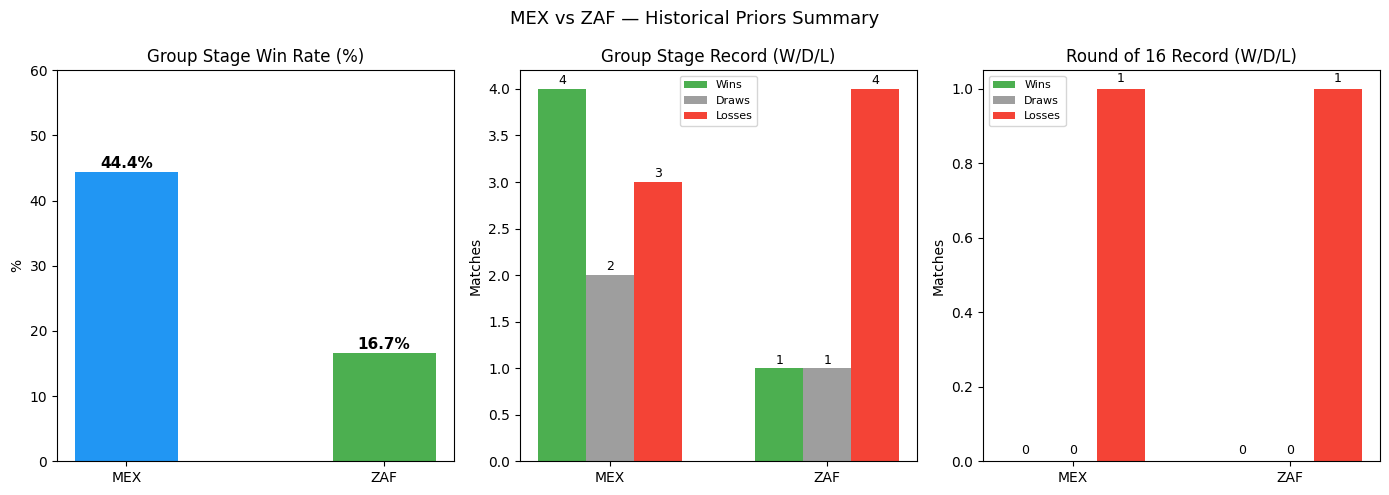

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

df_stage = priors_data["ads_a_stage_record"].copy()
df_stage["team"] = df_stage["country_id"].map({147: "MEX", 211: "ZAF"})
df_stage_group = df_stage[df_stage["stage_canonical"] == "group"]
df_stage_r16   = df_stage[df_stage["stage_canonical"] == "r16"]

colors = ["#2196F3", "#4CAF50"]
teams  = ["MEX", "ZAF"]
width  = 0.22

# ── Left: group stage win rate ────────────────────────────────
rates = [
    df_stage_group[df_stage_group["team"] == "MEX"]["win_rate"].values[0] * 100,
    df_stage_group[df_stage_group["team"] == "ZAF"]["win_rate"].values[0] * 100,
]
bars = axes[0].bar(teams, rates, color=colors, width=0.4)
axes[0].set_title("Group Stage Win Rate (%)")
axes[0].set_ylabel("%")
axes[0].set_ylim(0, 60)
for bar, val in zip(bars, rates):
    axes[0].annotate(f"{val:.1f}%",
                     (bar.get_x() + bar.get_width()/2, val + 0.5),
                     ha="center", fontsize=11, fontweight="bold")

# ── Middle: group stage W/D/L ─────────────────────────────────
x = range(2)
axes[1].bar([i - width for i in x],
            df_stage_group["wins"].values,
            width=width, color="#4CAF50", label="Wins")
axes[1].bar([i for i in x],
            df_stage_group["draws"].values,
            width=width, color="#9E9E9E", label="Draws")
axes[1].bar([i + width for i in x],
            df_stage_group["losses"].values,
            width=width, color="#F44336", label="Losses")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(["MEX", "ZAF"])
axes[1].set_title("Group Stage Record (W/D/L)")
axes[1].set_ylabel("Matches")
axes[1].legend(fontsize=8)
for i, row in enumerate(df_stage_group.itertuples()):
    axes[1].annotate(str(row.wins),   (i - width, row.wins   + 0.05), ha="center", fontsize=9)
    axes[1].annotate(str(row.draws),  (i,          row.draws  + 0.05), ha="center", fontsize=9)
    axes[1].annotate(str(row.losses), (i + width,  row.losses + 0.05), ha="center", fontsize=9)

# ── Right: R16 record (instead of broken penalty chart) ───────
r16_mex = df_stage_r16[df_stage_r16["team"] == "MEX"].iloc[0]
r16_zaf = df_stage_r16[df_stage_r16["team"] == "ZAF"].iloc[0]

r16_wins   = [r16_mex["wins"],   r16_zaf["wins"]]
r16_draws  = [r16_mex["draws"],  r16_zaf["draws"]]
r16_losses = [r16_mex["losses"], r16_zaf["losses"]]

axes[2].bar([i - width for i in x], r16_wins,   width=width, color="#4CAF50", label="Wins")
axes[2].bar([i          for i in x], r16_draws,  width=width, color="#9E9E9E", label="Draws")
axes[2].bar([i + width  for i in x], r16_losses, width=width, color="#F44336", label="Losses")
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(["MEX", "ZAF"])
axes[2].set_title("Round of 16 Record (W/D/L)")
axes[2].set_ylabel("Matches")
axes[2].legend(fontsize=8)
for i, (w, d, l) in enumerate(zip(r16_wins, r16_draws, r16_losses)):
    axes[2].annotate(str(int(w)), (i - width, w + 0.02), ha="center", fontsize=9)
    axes[2].annotate(str(int(d)), (i,          d + 0.02), ha="center", fontsize=9)
    axes[2].annotate(str(int(l)), (i + width,  l + 0.02), ha="center", fontsize=9)

plt.suptitle("MEX vs ZAF — Historical Priors Summary", fontsize=13)
plt.tight_layout()
plt.show()

## EDA Summary — Key Findings

### Identity Map
| System | Mexico | South Africa |
|--------|--------|--------------|
| Sportmonks team_id | 18576 | 18555 |
| Sportmonks country_id | 458 | 146 |
| Supabase dim_match | 458 | None |
| StatsBomb priors | 147 | 211 |
| Polymarket code | MEX | ZAF |

### Data Availability
| Source | Status |
|--------|--------|
| Sportmonks predictions | ✓ both teams |
| Sportmonks odds | ✓ both teams — 16 bookmakers |
| Sportmonks xG | ✗ empty on staging |
| Polymarket | ✓ both teams — $654k liquidity |
| Supabase checkpoint | ✓ Mexico only — ZAF didn't qualify 2022 |
| Supabase priors | ✓ both teams — with caveats |

### Signal Comparison
| Source | MEX | Draw | ZAF |
|--------|-----|------|-----|
| ML Models avg | 39.9% | 27.8% | 32.3% |
| Bookmakers | 70.1% | 23.0% | 12.7% |
| Polymarket | 68.5% | 20.5% | 10.5% |

### Key Findings
1. **30pp gap** between ML models and market on Mexico — biggest disagreement in this EDA
2. **Bookmakers and Polymarket agree** almost perfectly — markets are well arbitraged
3. **Mexico's 2022 form is opponent-dependent** — dominant vs weak teams, struggles vs strong
4. **Historical win rates** strongly favour Mexico — 44.4% vs ZAF's 16.7%
5. **Supabase data quality issues** — mixed tournaments, missing ZAF data, multiple ID systems

### TODOs
- [ ] Backtest: ML models vs bookmakers accuracy on 2022 WC
- [ ] Fix agent notebook with correct identity map
- [ ] Add identity resolution as Step 0 in agent loop